In [1]:
import pandas as pd
import matplotlib.pyplot as plt
datos_limpios= pd.read_pickle('../data/datos_arbolado')

In [37]:
datos_limpios['nombre_cientifico'].value_counts()

nombre_cientifico
Fraxinus pennsylvanica                 127973
Otra                                    54172
Platanus x acerifolia                   29960
Ficus benjamina                         21379
Tilia x moltkei                         14800
Melia azedarach                         14036
Jacaranda mimosifolia                   12790
Lagerstroemia indica                    11356
Fraxinus americana                       9621
Ligustrum lucidum                        8624
Fraxinus excelsior                       8201
Tipuana tipu                             8125
Ligustrum lucidum f. aureovariegata      7751
Liquidambar styraciflua                  5311
Acer negundo                             4892
Name: count, dtype: int64

In [213]:
flaxinus= datos_limpios[datos_limpios['altura_arbol']<20]
flaxinus= flaxinus[flaxinus['comuna']==9]


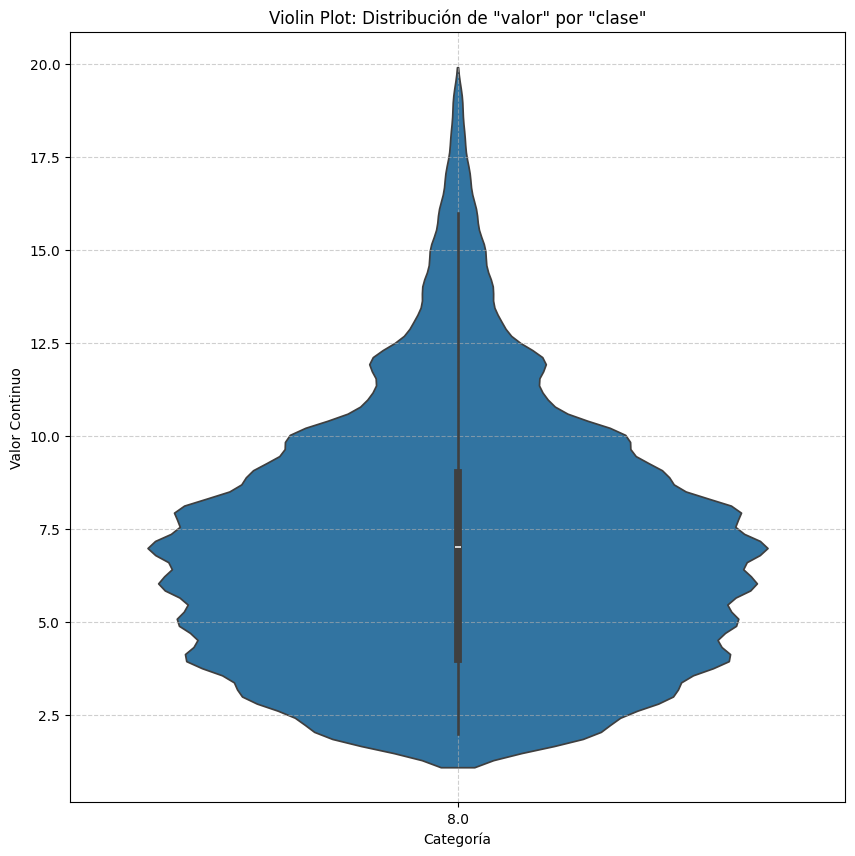

In [212]:
# (Usando el mismo DataFrame 'df' de antes)

import seaborn as sns
plt.figure(figsize=(10, 10))
sns.violinplot(x='comuna', y='altura_arbol', data=flaxinus)
plt.title('Violin Plot: Distribución de "valor" por "clase"')
plt.xlabel('Categoría')
plt.ylabel('Valor Continuo')
plt.grid(True, linestyle='--', alpha=0.6)


# plt.show()
# plt.savefig('violinplot_por_clase.png')

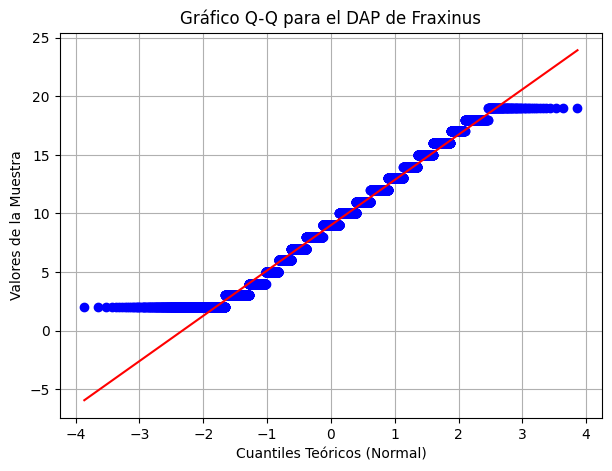

In [203]:
import scipy.stats as stats
import matplotlib.pyplot as plt

dap_flaxinus = flaxinus['altura_arbol']

plt.figure(figsize=(7, 5))
stats.probplot(dap_flaxinus, dist="norm", plot=plt)
plt.title('Gráfico Q-Q para el DAP de Fraxinus')
plt.xlabel('Cuantiles Teóricos (Normal)')
plt.ylabel('Valores de la Muestra')
plt.grid(True)
plt.show()

In [204]:
from scipy.stats import shapiro


dap_flaxinus = flaxinus['altura_arbol']

stat, p = shapiro(dap_flaxinus)
print(f"Test de Shapiro-Wilk: Estadístico={stat:.3f}, p-valor={p:.3f}")

Test de Shapiro-Wilk: Estadístico=0.981, p-valor=0.000


/home/atreus/workspace/repositorios_ingenieria/TP-Ciencia-De-Datos-Grupo14/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 12447.
  res = hypotest_fun_out(*samples, **kwds)


In [201]:
from scipy.stats import kstest

# Test de Kolmogorov-Smirnov para países desarrollados
stat, p = kstest(dap_flaxinus, 'norm')
print(f"Test de Kolmogorov-Smirnov para países desarrollados: Estadístico={stat:.3f}, p-valor={p:.3f}")



Test de Kolmogorov-Smirnov para países desarrollados: Estadístico=0.977, p-valor=0.000


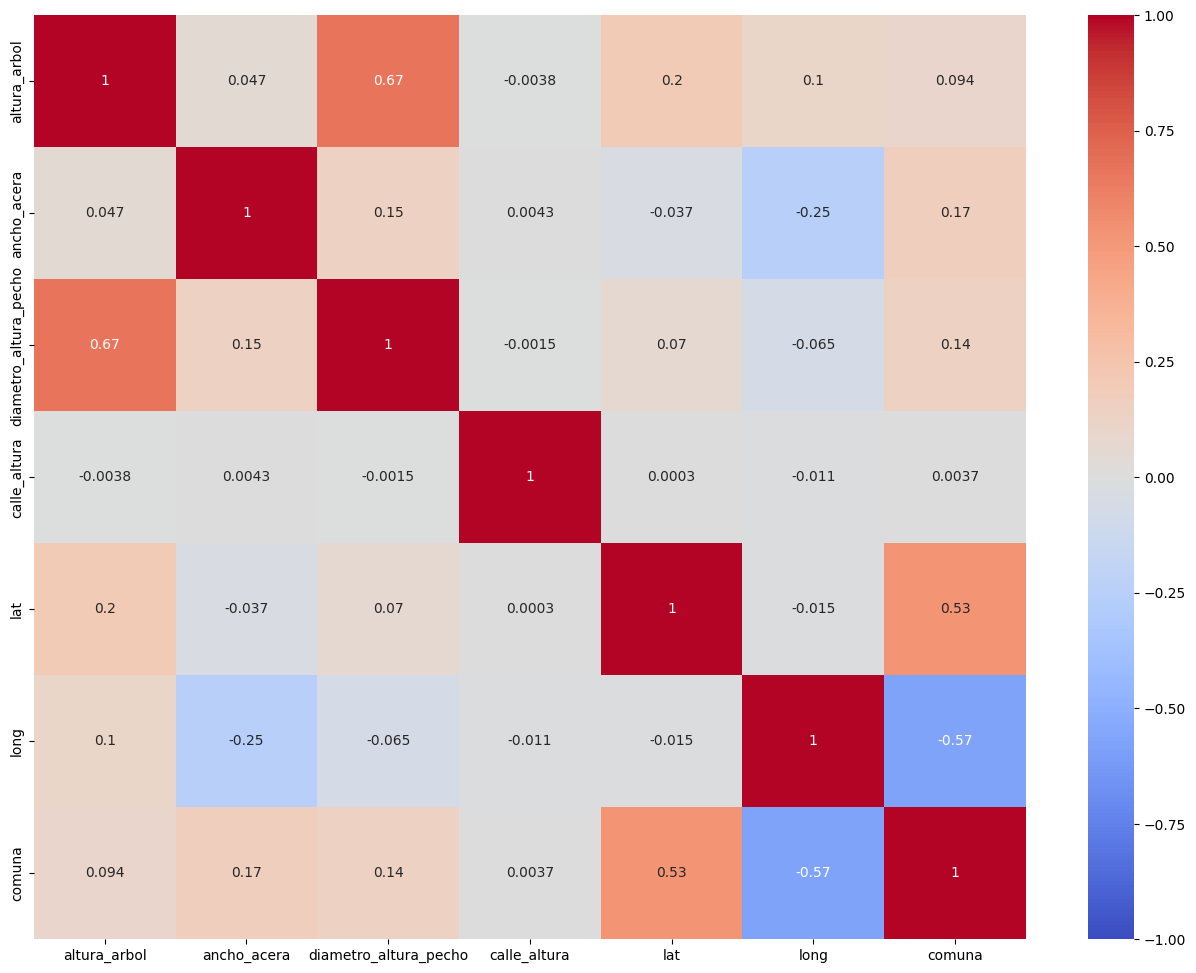

In [170]:
dato=flaxinus[['altura_arbol', 'ancho_acera', 'diametro_altura_pecho','calle_altura','lat','long','comuna']].corr(method='pearson')


import seaborn as sns
import matplotlib.pyplot as plt

# imprimimos la matriz como un heatmap
plt.figure(figsize=(16,12))
sns.heatmap(dato, vmin=-1.0, vmax=1.0, center=0.0, annot=True, cmap= 'coolwarm')
plt.show()

In [84]:
import numpy as np
import statsmodels.api as sm
# Separamos nuestra variable independiente
X = flaxinus[['altura_arbol']]
# y nuestra variable objetivo (variable dependiente)
y = flaxinus['comuna']

# Agregamos una constante como característica, para estimar la ordenada al origen
X = sm.add_constant(X)
# Ajustamos el modelo
model = sm.OLS(y, X).fit()
# Imprimimos el resumen de los resultados
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 comuna   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     62.99
Date:                Sat, 15 Nov 2025   Prob (F-statistic):           2.25e-15
Time:                        01:08:50   Log-Likelihood:                -37500.
No. Observations:               12790   AIC:                         7.500e+04
Df Residuals:                   12788   BIC:                         7.502e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            8.1185      0.087     93.684   